# City of Austin — Pedestrian Crosswalk & ADA Accessibility Analysis
**Full pipeline**: data acquisition → compliance scoring → priority tiering → visualizations → markdown report generation

In [1]:
# ── Section 0.1 — Imports & constants ────────────────────────────────────────
import urllib.request
import urllib.parse
import json
import time
import pathlib
import warnings
import re

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, shape
from shapely import STRtree
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

BASE_DIR  = pathlib.Path('/Users/brownfamily/Documents/Pedestrian Crosswalk & ADA Accessibility Analysis')
DATA_RAW  = BASE_DIR / 'data' / 'raw'
DATA_PROC = BASE_DIR / 'data' / 'processed'
FIGURES   = BASE_DIR / 'outputs' / 'figures'

for d in [DATA_RAW, DATA_PROC, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print('Base dir:', BASE_DIR)

Environment ready.
Base dir: /Users/brownfamily/Documents/Pedestrian Crosswalk & ADA Accessibility Analysis


In [2]:
# ── Section 0.2 — API helper functions ───────────────────────────────────────

SOCRATA_BASE = 'https://data.austintexas.gov/resource'
ARCGIS_BASE  = 'https://services.arcgis.com/0L95CJ0VTaxqcmED/arcgis/rest/services'
CENSUS_BASE  = 'https://api.census.gov/data/2022/acs/acs5'


def _http_get(url, retries=3, backoff=2.0):
    req = urllib.request.Request(url, headers={'User-Agent': 'AustinADA-Analysis/1.0'})
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(req, timeout=60) as r:
                return json.loads(r.read().decode())
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(backoff * (attempt + 1))
            else:
                raise RuntimeError(f'HTTP GET failed after {retries} attempts: {url}\n{e}')


def fetch_socrata_paginated(dataset_id, select='*', where=None, page_size=50_000):
    rows, offset = [], 0
    while True:
        params = {'$select': select, '$limit': page_size, '$offset': offset}
        if where:
            params['$where'] = where
        qs = urllib.parse.urlencode(params)
        url = f'{SOCRATA_BASE}/{dataset_id}.json?{qs}'
        batch = _http_get(url)
        rows.extend(batch)
        print(f'  fetched {len(rows):,} rows...', end='\r')
        if len(batch) < page_size:
            break
        offset += page_size
    print(f'  → {len(rows):,} total rows')
    return rows


def fetch_arcgis_features(service_name, layer=0, fields='*', where='1=1', batch_size=1000):
    features, offset = [], 0
    while True:
        params = {
            'where': where, 'outFields': fields, 'f': 'geojson',
            'resultOffset': offset, 'resultRecordCount': batch_size
        }
        qs = urllib.parse.urlencode(params)
        url = f'{ARCGIS_BASE}/{service_name}/FeatureServer/{layer}/query?{qs}'
        data = _http_get(url)
        batch = data.get('features', [])
        features.extend(batch)
        print(f'  fetched {len(features):,} features...', end='\r')
        if not data.get('exceededTransferLimit', False):
            break
        offset += batch_size
        time.sleep(0.4)
    print(f'  → {len(features):,} total features')
    geojson = {'type': 'FeatureCollection', 'features': features}
    return gpd.GeoDataFrame.from_features(geojson, crs='EPSG:4326')


def fetch_census_acs(state, county, variables):
    var_str = ','.join(['NAME'] + variables)
    params = {'get': var_str, 'for': 'tract:*', 'in': f'state:{state} county:{county}'}
    qs = urllib.parse.urlencode(params)
    url = f'{CENSUS_BASE}?{qs}'
    data = _http_get(url)
    cols = data[0]
    rows = data[1:]
    return pd.DataFrame(rows, columns=cols)


def load_or_fetch(path, fetch_fn, *args, **kwargs):
    path = pathlib.Path(path)
    if path.exists():
        print(f'  [cache] loading {path.name}')
        if path.suffix == '.csv':
            return pd.read_csv(path, low_memory=False)
        elif path.suffix in ('.geojson', '.json'):
            try:
                return gpd.read_file(path)
            except Exception:
                with open(path) as f:
                    return json.load(f)
    result = fetch_fn(*args, **kwargs)
    if isinstance(result, gpd.GeoDataFrame):
        result.to_file(path, driver='GeoJSON')
    elif isinstance(result, pd.DataFrame):
        result.to_csv(path, index=False)
    elif isinstance(result, (list, dict)):
        with open(path, 'w') as f:
            json.dump(result, f)
    return result


print('Helper functions defined.')

Helper functions defined.


## Section 1 — Data Acquisition

In [3]:
# ── 1.1 Sidewalk inventory (Socrata vchz-d9ng) ───────────────────────────────
print('Fetching sidewalk inventory...')

sidewalk_path = DATA_RAW / 'sidewalks.csv'
if not sidewalk_path.exists():
    rows = fetch_socrata_paginated(
        'vchz-d9ng',
        select='objectid,sidewalks_id,full_street_name,pedestrian_facility_type,'
               'functional_condition,rating_overall,rating_final,rating_curbramp,'
               'council_district,width_sidewalk,sidewalk_surface,status,the_geom',
        where="status='ACTIVE'"
    )
    df_sw = pd.DataFrame(rows)
    df_sw.to_csv(sidewalk_path, index=False)
    print(f'Saved {len(df_sw):,} rows → sidewalks.csv')
else:
    df_sw = pd.read_csv(sidewalk_path, low_memory=False)
    print(f'[cache] sidewalks.csv — {len(df_sw):,} rows')

Fetching sidewalk inventory...


  fetched 313,389 rows...
  → 313,389 total rows


Saved 313,389 rows → sidewalks.csv


In [4]:
# ── 1.2 Curb ramps (ArcGIS TRANSPORTATION_curb_ramps) ────────────────────────
print('Fetching curb ramps...')
gdf_ramps = load_or_fetch(
    DATA_RAW / 'curb_ramps.geojson',
    fetch_arcgis_features,
    'TRANSPORTATION_curb_ramps',
    fields='OBJECTID,RATING,DETECTABLE_WARNING,CURB_RAMP_TYPE,STATUS,CURB_RAMP_ADA_TYPE',
    where="STATUS='ACTIVE'"
)
print(f'Curb ramps: {len(gdf_ramps):,} records')

Fetching curb ramps...


  fetched 1,000 features...
  → 1,000 total features
Curb ramps: 1,000 records


In [5]:
# ── 1.3 Traffic signals (Socrata p53x-x73x) ──────────────────────────────────
print('Fetching traffic signals...')
sig_path = DATA_RAW / 'signals.csv'
if not sig_path.exists():
    rows = fetch_socrata_paginated(
        'p53x-x73x',
        select='signal_id,signal_type,signal_status,leading_pedestrian_interval,'
               'council_district,location'
    )
    df_sig = pd.DataFrame(rows)
    df_sig.to_csv(sig_path, index=False)
    print(f'Saved {len(df_sig):,} rows → signals.csv')
else:
    df_sig = pd.read_csv(sig_path)
    print(f'[cache] signals.csv — {len(df_sig):,} rows')

Fetching traffic signals...


  fetched 1,331 rows...
  → 1,331 total rows
Saved 1,331 rows → signals.csv


In [6]:
# ── 1.4 Point-of-interest datasets ───────────────────────────────────────────
print('Fetching schools...')
gdf_schools = load_or_fetch(
    DATA_RAW / 'schools.geojson',
    fetch_arcgis_features,
    'AISD_Schools',
    fields='OBJECTID,NAME,GRD_RANGE,SCHL_TYPE,SCHL_STATU,ADDRESS'
)
print(f'Schools: {len(gdf_schools):,}')

print('Fetching transit stops...')
gdf_transit = load_or_fetch(
    DATA_RAW / 'transit_stops.geojson',
    fetch_arcgis_features,
    'EXTERNAL_cmta_stops',
    fields='OBJECTID,STOP_ID,STOP_NAME,STOP_TYPE,STATUS'
)
print(f'Transit stops: {len(gdf_transit):,}')

print('Fetching hospitals...')
gdf_hospitals = load_or_fetch(
    DATA_RAW / 'hospitals.geojson',
    fetch_arcgis_features,
    'Hospitals_services',
    fields='OBJECTID,FACILITY_NAME,FACILITY_TYPE,ADDRESS,CITY'
)
print(f'Hospitals: {len(gdf_hospitals):,}')

Fetching schools...


  fetched 151 features...
  → 151 total features
Schools: 151
Fetching transit stops...


  fetched 1,000 features...
  → 1,000 total features
Transit stops: 1,000
Fetching hospitals...


  fetched 20 features...
  → 20 total features
Hospitals: 20


In [7]:
# ── 1.5 Council district boundaries ──────────────────────────────────────────
print('Fetching council districts...')
gdf_districts = load_or_fetch(
    DATA_RAW / 'council_districts.geojson',
    fetch_arcgis_features,
    'Council_Districts',
    fields='*'
)
print(f'Districts: {len(gdf_districts):,}')
print(gdf_districts.columns.tolist())

Fetching council districts...


  fetched 10 features...
  → 10 total features
Districts: 10
['geometry', 'FID', 'OBJECTID', 'SINGLE_MEM', 'CREATED_DA', 'CREATED_BY', 'MODIFIED_D', 'MODIFIED_B', 'COUNCIL_DI', 'COUNCIL__1', 'SHAPE_AREA', 'SHAPE_LEN', 'Shape__Area', 'Shape__Length', 'PIT_2016', 'PIT_2017', 'Percent_Change']


In [8]:
# ── 1.6 311 ADA/sidewalk complaints ──────────────────────────────────────────
print('Fetching 311 complaints...')
cmp_path = DATA_RAW / 'complaints_311.csv'
if not cmp_path.exists():
    ada_types = [
        'Sidewalk Repair', 'Sidewalk/Curb Ramp/Route - NEW',
        'TPW - Sidewalk Repair', 'SBO - Sidewalk Repair',
        'Curb/Gutter Repair', 'ATD - Bicycle & Pedestrian Issues'
    ]
    type_filter = ' OR '.join([f"sr_type_desc='{t}'" for t in ada_types])
    rows = fetch_socrata_paginated(
        'xwdj-i9he',
        select='sr_type_desc,sr_location_lat,sr_location_long,sr_created_date,sr_status_desc',
        where=type_filter
    )
    df_complaints = pd.DataFrame(rows)
    df_complaints.to_csv(cmp_path, index=False)
    print(f'Saved {len(df_complaints):,} rows → complaints_311.csv')
else:
    df_complaints = pd.read_csv(cmp_path)
    print(f'[cache] complaints_311.csv — {len(df_complaints):,} rows')

Fetching 311 complaints...


  fetched 20,330 rows...
  → 20,330 total rows
Saved 20,330 rows → complaints_311.csv


In [9]:
# ── 1.7 Census ACS5 demographics (Travis County, TX) ─────────────────────────
print('Fetching Census ACS5 demographics...')
census_path = DATA_RAW / 'census_travis_county.json'
if not census_path.exists():
    census_vars = [
        'B01001_001E',                              # total population
        'B01001_020E','B01001_021E','B01001_022E',  # male 65-69, 70-74, 75-79
        'B01001_023E','B01001_024E','B01001_025E',  # male 80-84, 85+
        'B01001_044E','B01001_045E','B01001_046E',  # female 65-69, 70-74, 75-79
        'B01001_047E','B01001_048E','B01001_049E',  # female 80-84, 85+
        'B18101_001E',                              # civilian pop (disability denom)
        'B18101_004E','B18101_007E','B18101_010E',  # male disability by age
        'B18101_023E','B18101_026E','B18101_029E',  # female disability by age
    ]
    df_census = fetch_census_acs(state='48', county='453', variables=census_vars)
    df_census.to_json(census_path, orient='records')
    print(f'Saved {len(df_census):,} census tracts')
else:
    df_census = pd.read_json(census_path)
    print(f'[cache] census_travis_county.json — {len(df_census):,} tracts')

Fetching Census ACS5 demographics...


Saved 290 census tracts


## Section 2 — Data Cleaning & Geospatial Loading

In [10]:
# ── 2.1 Parse sidewalk geometries & filter ────────────────────────────────────
print('Processing sidewalk geometries...')

def parse_geom(val):
    if pd.isna(val) or val == '':
        return None
    try:
        if isinstance(val, str):
            val = json.loads(val)
        return shape(val)
    except Exception:
        return None

df_sw['geometry'] = df_sw['the_geom'].apply(parse_geom)
gdf_sw = gpd.GeoDataFrame(df_sw, geometry='geometry', crs='EPSG:4326')

# Filter to existing active sidewalks
mask = (gdf_sw['pedestrian_facility_type'] == 'EXISTING_SIDEWALK') & \
       (gdf_sw['status'] == 'ACTIVE') & \
       (gdf_sw['geometry'].notna())
gdf_sw = gdf_sw[mask].copy()
print(f'Existing active sidewalk segments: {len(gdf_sw):,}')

# Reproject to Texas State Plane Central (feet) for distance math
gdf_sw = gdf_sw.to_crs('EPSG:2277')
# Use centroid for point-based proximity analysis
gdf_sw['centroid'] = gdf_sw.geometry.centroid

# Numeric rating
gdf_sw['rating_final'] = pd.to_numeric(gdf_sw['rating_final'], errors='coerce')
gdf_sw['rating_curbramp'] = pd.to_numeric(gdf_sw['rating_curbramp'], errors='coerce')
print('Sidewalk data ready.')

Processing sidewalk geometries...


Existing active sidewalk segments: 175,609
Sidewalk data ready.


In [11]:
# ── 2.2 Reproject all POI datasets ────────────────────────────────────────────
CRS_PROJ = 'EPSG:2277'

for gdf, name in [
    (gdf_ramps,    'curb_ramps'),
    (gdf_schools,  'schools'),
    (gdf_transit,  'transit_stops'),
    (gdf_hospitals,'hospitals'),
    (gdf_districts,'districts'),
]:
    if gdf.crs and gdf.crs.to_epsg() != 2277:
        gdf.to_crs(CRS_PROJ, inplace=True)
    gdf.dropna(subset=['geometry'], inplace=True)
    print(f'{name}: {len(gdf):,} valid records, CRS={gdf.crs.to_epsg()}')

curb_ramps: 1,000 valid records, CRS=2277
schools: 151 valid records, CRS=2277
transit_stops: 1,000 valid records, CRS=2277
hospitals: 16 valid records, CRS=2277
districts: 10 valid records, CRS=2277


In [12]:
# ── 2.3 Identify council district column & normalize ─────────────────────────
print('District columns:', gdf_districts.columns.tolist())

# Find the district number column (usually COUNCIL_DI or similar)
dist_col = None
for c in gdf_districts.columns:
    if 'council' in c.lower() or 'district' in c.lower() or c.upper() in ('DISTNUM', 'DIST_ID'):
        dist_col = c
        break
if dist_col is None:
    dist_col = gdf_districts.columns[0]
    print(f'Warning: guessing district column = {dist_col}')

gdf_districts = gdf_districts.rename(columns={dist_col: 'council_district'})
gdf_districts['council_district'] = pd.to_numeric(gdf_districts['council_district'], errors='coerce')
print('District values:', sorted(gdf_districts['council_district'].dropna().unique().tolist()))

District columns: ['geometry', 'FID', 'OBJECTID', 'SINGLE_MEM', 'CREATED_DA', 'CREATED_BY', 'MODIFIED_D', 'MODIFIED_B', 'COUNCIL_DI', 'COUNCIL__1', 'SHAPE_AREA', 'SHAPE_LEN', 'Shape__Area', 'Shape__Length', 'PIT_2016', 'PIT_2017', 'Percent_Change']
District values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [13]:
# ── 2.4 Spatial join sidewalk centroids → council districts ──────────────────
print('Spatial joining sidewalks to council districts...')

gdf_sw_pts = gpd.GeoDataFrame(gdf_sw[['objectid']].copy(),
                               geometry=gdf_sw['centroid'],
                               crs=CRS_PROJ)

joined = gpd.sjoin(gdf_sw_pts, gdf_districts[['council_district','geometry']],
                   how='left', predicate='within')

gdf_sw['council_district_geo'] = joined['council_district'].values

# Use existing council_district column if geo join missed some
if 'council_district' in gdf_sw.columns:
    gdf_sw['council_district_final'] = pd.to_numeric(
        gdf_sw['council_district'], errors='coerce'
    ).fillna(gdf_sw['council_district_geo'])
else:
    gdf_sw['council_district_final'] = gdf_sw['council_district_geo']

dist_coverage = gdf_sw['council_district_final'].notna().sum()
print(f'Sidewalk segments with district: {dist_coverage:,} / {len(gdf_sw):,}')
print('Districts present:', sorted(gdf_sw['council_district_final'].dropna().unique().astype(int).tolist()))

Spatial joining sidewalks to council districts...
Sidewalk segments with district: 158,997 / 175,609
Districts present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## Section 3 — ADA Compliance Scoring

In [14]:
# ── 3.1 Compliance classification ────────────────────────────────────────────
def classify_compliance(rating):
    if pd.isna(rating):
        return 'UNKNOWN'
    r = int(rating)
    if r == 1:      return 'FULLY_COMPLIANT'
    elif r <= 3:    return 'PARTIALLY_COMPLIANT'
    elif r <= 5:    return 'NON_COMPLIANT'
    else:           return 'CRITICAL'

gdf_sw['compliance'] = gdf_sw['rating_final'].apply(classify_compliance)
print(gdf_sw['compliance'].value_counts())

compliance
PARTIALLY_COMPLIANT    75361
NON_COMPLIANT          41494
FULLY_COMPLIANT        31970
UNKNOWN                26784
Name: count, dtype: int64

In [15]:
# ── 3.2 Curb ramp deficiency scoring ─────────────────────────────────────────
def ramp_deficiency(rating, tactile):
    r = int(rating) if not pd.isna(rating) else 4
    score = {1: 0, 2: 1, 3: 2}.get(r, 4)
    if pd.isna(tactile) or str(tactile).strip() == '':
        score += 1  # missing tactile warning
    return score

if 'RATING' in gdf_ramps.columns:
    gdf_ramps['deficiency_score'] = gdf_ramps.apply(
        lambda row: ramp_deficiency(row.get('RATING'), row.get('DETECTABLE_WARNING')), axis=1
    )
    print('Ramp deficiency distribution:')
    print(gdf_ramps['deficiency_score'].value_counts().sort_index())
else:
    print('WARNING: RATING column not found in curb ramps. Columns:', gdf_ramps.columns.tolist())
    gdf_ramps['deficiency_score'] = 0

Ramp deficiency distribution:
deficiency_score
0    335
1    232
2    115
3     90
4      6
5    222
Name: count, dtype: int64


In [16]:
# ── 3.3 Proximity scoring using STRtree ──────────────────────────────────────
print('Building proximity scores (this may take ~30s)...')

def proximity_scores(seg_centroids, poi_geoms, distance_ft, score_max=5.0):
    """Return a Series of scores 0..score_max based on nearest POI distance."""
    tree = STRtree(poi_geoms)
    scores = []
    for pt in seg_centroids:
        idx = tree.nearest(pt)
        dist = pt.distance(poi_geoms[idx])
        if dist <= distance_ft:
            # Linear score: full points at 0, 0 points at threshold
            scores.append(score_max * (1 - dist / distance_ft))
        else:
            scores.append(0.0)
    return np.array(scores)

centroids = list(gdf_sw['centroid'])

SCHOOL_FT   = 1320.0  # 1/4 mile
TRANSIT_FT  = 500.0
HOSPITAL_FT = 2640.0  # 1/2 mile

school_geoms   = list(gdf_schools.geometry)
transit_geoms  = list(gdf_transit.geometry)
hospital_geoms = list(gdf_hospitals.geometry)

print('  Computing school proximity...')
gdf_sw['prox_school']   = proximity_scores(centroids, school_geoms,   SCHOOL_FT,   5.0)
print('  Computing transit proximity...')
gdf_sw['prox_transit']  = proximity_scores(centroids, transit_geoms,  TRANSIT_FT,  5.0)
print('  Computing hospital proximity...')
gdf_sw['prox_hospital'] = proximity_scores(centroids, hospital_geoms, HOSPITAL_FT, 5.0)
print('Proximity scores done.')

Building proximity scores (this may take ~30s)...
  Computing school proximity...


  Computing transit proximity...


  Computing hospital proximity...


Proximity scores done.


In [17]:
# ── 3.4 Risk score (40% weight) ──────────────────────────────────────────────

# 311 complaint density by district (normalized 0-10)
if 'council_district' in df_complaints.columns:
    cmp_by_dist = df_complaints['council_district'].value_counts().to_dict()
else:
    # Try to spatial join complaints to districts
    df_complaints['lat'] = pd.to_numeric(df_complaints.get('sr_location_lat', None), errors='coerce')
    df_complaints['lon'] = pd.to_numeric(df_complaints.get('sr_location_long', None), errors='coerce')
    valid_cmp = df_complaints.dropna(subset=['lat','lon'])
    gdf_cmp = gpd.GeoDataFrame(
        valid_cmp,
        geometry=[Point(row.lon, row.lat) for _, row in valid_cmp.iterrows()],
        crs='EPSG:4326'
    ).to_crs(CRS_PROJ)
    cmp_joined = gpd.sjoin(gdf_cmp[['geometry']], gdf_districts[['council_district','geometry']],
                           how='left', predicate='within')
    cmp_by_dist = cmp_joined['council_district'].value_counts().to_dict()

max_complaints = max(cmp_by_dist.values()) if cmp_by_dist else 1

def usage_score(district):
    if pd.isna(district):
        return 5.0
    return 10.0 * cmp_by_dist.get(district, 0) / max_complaints

gdf_sw['usage_frequency'] = gdf_sw['council_district_final'].apply(usage_score)

# Safety hazard from rating (inverse: higher rating = worse)
def safety_hazard_score(rating):
    if pd.isna(rating): return 5.0
    return min(10.0, float(rating) * 2.0 - 1.0)  # 1→1, 2→3, 3→5, 4→7, 5→9, 6→10

gdf_sw['safety_hazard'] = gdf_sw['rating_final'].apply(safety_hazard_score)

# Population vulnerability: senior density by district (from Census)
senior_vars = ['B01001_020E','B01001_021E','B01001_022E','B01001_023E','B01001_024E','B01001_025E',
               'B01001_044E','B01001_045E','B01001_046E','B01001_047E','B01001_048E','B01001_049E']
tot_var = 'B01001_001E'

for col in senior_vars + [tot_var]:
    if col in df_census.columns:
        df_census[col] = pd.to_numeric(df_census[col], errors='coerce').clip(lower=0)

available_senior_vars = [v for v in senior_vars if v in df_census.columns]
df_census['senior_pop'] = df_census[available_senior_vars].sum(axis=1) if available_senior_vars else 0
df_census['total_pop']  = pd.to_numeric(df_census.get(tot_var, pd.Series([0]*len(df_census))), errors='coerce').fillna(0)

city_senior_rate = df_census['senior_pop'].sum() / max(df_census['total_pop'].sum(), 1)
print(f'Travis County senior rate (65+): {city_senior_rate:.1%}')

# Use uniform senior vulnerability score (county-level) — no tract-to-district mapping here
gdf_sw['pop_vulnerability'] = 10.0 * city_senior_rate / 0.15  # normalize to ~0-10

# Cumulative deficiency: number of problem types at location
gdf_sw['cumulative_def'] = (
    (gdf_sw['rating_final'] >= 4).astype(float) * 2
    + (gdf_sw['rating_curbramp'] >= 3).astype(float) * 2
    + (gdf_sw['prox_school'] > 0).astype(float)
).clip(0, 5)

gdf_sw['risk_score'] = (
    gdf_sw[['safety_hazard','pop_vulnerability','usage_frequency']].mean(axis=1) * 0.40
    + gdf_sw['cumulative_def'] * 0.10
)
print('Risk scores computed.')

Travis County senior rate (65+): 10.4%
Risk scores computed.


In [18]:
# ── 3.5 Equity, Feasibility & Impact scores ──────────────────────────────────

# Geographic equity: lower-numbered districts in Austin tend to be lower-income
# District 1,2,3,4,5 = east/south Austin (historically underserved)
EQUITY_DISTRICT = {1:10, 2:9, 3:10, 4:8, 5:9, 6:5, 7:4, 8:3, 9:6, 10:4}

def geo_equity(district):
    if pd.isna(district): return 5.0
    return float(EQUITY_DISTRICT.get(int(district), 5))

gdf_sw['geo_equity'] = gdf_sw['council_district_final'].apply(geo_equity)
gdf_sw['senior_density_score'] = 10.0 * city_senior_rate / 0.15

gdf_sw['equity_score'] = (
    gdf_sw['geo_equity'] * 0.10
    + gdf_sw['prox_school'] * 0.05
    + gdf_sw['prox_transit'] * 0.05
    + gdf_sw['prox_hospital'] * 0.05
    + gdf_sw['senior_density_score'] * 0.05
)

# Feasibility: shorter/simpler repairs score higher
gdf_sw['cost_efficiency']   = 10.0 - (gdf_sw['rating_final'].fillna(3) - 1) * 2.0
gdf_sw['feasibility_score'] = gdf_sw['cost_efficiency'].clip(0, 10) * 0.20

# Impact: normalize by district population (proxy)
DISTRICT_POP = {1:85000, 2:85000, 3:85000, 4:85000, 5:85000,
                6:90000, 7:88000, 8:92000, 9:75000, 10:88000}
max_pop = max(DISTRICT_POP.values())

def impact_score(district):
    if pd.isna(district): return 5.0
    return 10.0 * DISTRICT_POP.get(int(district), 85000) / max_pop

gdf_sw['impact_score'] = gdf_sw['council_district_final'].apply(impact_score) * 0.10

print('Equity, feasibility, and impact scores computed.')

Equity, feasibility, and impact scores computed.


In [19]:
# ── 3.6 Priority tier classification ─────────────────────────────────────────
gdf_sw['total_score'] = (
    gdf_sw['risk_score']
    + gdf_sw['equity_score']
    + gdf_sw['feasibility_score']
    + gdf_sw['impact_score']
).clip(0, 40)

def assign_tier(score):
    if score >= 35: return 'Tier 1 - Critical'
    elif score >= 28: return 'Tier 2 - High'
    elif score >= 20: return 'Tier 3 - Medium'
    elif score >= 10: return 'Tier 4 - Low'
    else:             return 'Deferred'

gdf_sw['tier'] = gdf_sw['total_score'].apply(assign_tier)

print('Priority tier distribution:')
print(gdf_sw['tier'].value_counts())

# Save scored sidewalks
save_cols = [
    'objectid','full_street_name','council_district_final','compliance','rating_final',
    'risk_score','equity_score','feasibility_score','impact_score','total_score','tier',
    'prox_school','prox_transit','prox_hospital'
]
gdf_sw[save_cols].to_csv(DATA_PROC / 'sidewalks_scored.csv', index=False)
print('Saved sidewalks_scored.csv')

Priority tier distribution:
tier
Deferred    175609
Name: count, dtype: int64


Saved sidewalks_scored.csv


## Section 4 — Statistical Aggregation

In [20]:
# ── 4.1 Citywide compliance statistics ───────────────────────────────────────
comp_counts = gdf_sw['compliance'].value_counts()
total_assessed = len(gdf_sw)
known = gdf_sw[gdf_sw['compliance'] != 'UNKNOWN']
total_known = len(known)

n_fully     = (known['compliance'] == 'FULLY_COMPLIANT').sum()
n_partial   = (known['compliance'] == 'PARTIALLY_COMPLIANT').sum()
n_non       = (known['compliance'] == 'NON_COMPLIANT').sum()
n_critical  = (known['compliance'] == 'CRITICAL').sum()
n_unknown   = (gdf_sw['compliance'] == 'UNKNOWN').sum()

pct_fully    = round(n_fully   / total_known * 100, 1) if total_known > 0 else 0
pct_partial  = round(n_partial / total_known * 100, 1) if total_known > 0 else 0
pct_non      = round(n_non     / total_known * 100, 1) if total_known > 0 else 0
pct_critical = round(n_critical / total_known * 100, 1) if total_known > 0 else 0

print(f'Total sidewalk segments assessed: {total_assessed:,}')
print(f'  Fully Compliant:     {n_fully:,}  ({pct_fully}%)')
print(f'  Partially Compliant: {n_partial:,}  ({pct_partial}%)')
print(f'  Non-Compliant:       {n_non:,}  ({pct_non}%)')
print(f'  Critical:            {n_critical:,}  ({pct_critical}%)')
print(f'  Unknown/Pending:     {n_unknown:,}')

Total sidewalk segments assessed: 175,609
  Fully Compliant:     31,970  (21.5%)
  Partially Compliant: 75,361  (50.6%)
  Non-Compliant:       41,494  (27.9%)
  Critical:            0  (0.0%)
  Unknown/Pending:     26,784


In [21]:
# ── 4.2 Deficiency counts ─────────────────────────────────────────────────────

# Curb ramp deficiencies
if 'RATING' in gdf_ramps.columns:
    gdf_ramps['RATING'] = pd.to_numeric(gdf_ramps['RATING'], errors='coerce')
    n_ramp_installs  = int((gdf_ramps['RATING'] >= 4).sum())
    n_ramp_repairs   = int(((gdf_ramps['RATING'] >= 3) & (gdf_ramps['RATING'] < 4)).sum())
    n_missing_tactile = int(gdf_ramps['DETECTABLE_WARNING'].isna().sum()) if 'DETECTABLE_WARNING' in gdf_ramps.columns else 0
else:
    n_ramp_installs, n_ramp_repairs, n_missing_tactile = 0, 0, 0

# Signal deficiencies
if 'leading_pedestrian_interval' in df_sig.columns:
    n_signals_total = len(df_sig)
    n_signals_lpi   = int((df_sig['leading_pedestrian_interval'].astype(str).str.lower() == 'true').sum())
    n_signals_no_lpi = n_signals_total - n_signals_lpi
else:
    n_signals_total, n_signals_lpi, n_signals_no_lpi = len(df_sig), 0, 0

# Surface hazards
n_surface_poor     = int((gdf_sw['rating_final'] == 4).sum())
n_surface_failed   = int((gdf_sw['rating_final'] >= 5).sum())
n_surface_hazards  = n_surface_poor + n_surface_failed

print(f'Deficient curb ramps (needs install):  {n_ramp_installs:,}')
print(f'Curb ramps needing repair:             {n_ramp_repairs:,}')
print(f'Missing tactile warnings:              {n_missing_tactile:,}')
print(f'Signals lacking LPI:                   {n_signals_no_lpi:,} of {n_signals_total:,}')
print(f'Surface hazards (poor/failed):         {n_surface_hazards:,}')

Deficient curb ramps (needs install):  167
Curb ramps needing repair:             93
Missing tactile warnings:              644
Signals lacking LPI:                   1,007 of 1,331
Surface hazards (poor/failed):         41,494


In [22]:
# ── 4.3 District-level aggregation ───────────────────────────────────────────
district_stats = gdf_sw.groupby('council_district_final').agg(
    total_segments=('objectid', 'count'),
    fully_compliant=('compliance', lambda x: (x == 'FULLY_COMPLIANT').sum()),
    non_compliant=('compliance', lambda x: (x == 'NON_COMPLIANT').sum()),
    critical=('compliance', lambda x: (x == 'CRITICAL').sum()),
    avg_score=('total_score', 'mean'),
    tier1_count=('tier', lambda x: (x == 'Tier 1 - Critical').sum()),
    tier2_count=('tier', lambda x: (x == 'Tier 2 - High').sum()),
).reset_index()

known_mask = gdf_sw['compliance'] != 'UNKNOWN'
known_by_dist = gdf_sw[known_mask].groupby('council_district_final').agg(
    known_count=('objectid', 'count'),
    known_compliant=('compliance', lambda x: (x == 'FULLY_COMPLIANT').sum())
).reset_index()

district_stats = district_stats.merge(known_by_dist, on='council_district_final', how='left')
district_stats['compliance_rate'] = (district_stats['known_compliant'] / district_stats['known_count'] * 100).round(1)
district_stats = district_stats.dropna(subset=['council_district_final'])
district_stats['council_district_final'] = district_stats['council_district_final'].astype(int)
district_stats = district_stats.sort_values('council_district_final')

print(district_stats[['council_district_final','total_segments','compliance_rate','avg_score','tier1_count']].to_string(index=False))

 council_district_final  total_segments  compliance_rate  avg_score  tier1_count
                      1           21121             30.8   5.818305            0
                      2           22732             23.2   5.599024            0
                      3           10937             27.2   5.751744            0
                      4           10980             29.0   5.343340            0
                      5           18814             20.8   5.655371            0
                      6           17720             15.6   4.996362            0
                      7           15580             16.7   5.176804            0
                      8           19188             14.1   4.917394            0
                      9           11391             27.5   6.110952            0
                     10           10534             13.2   4.972971            0


In [23]:
# ── 4.4 Cost estimation ───────────────────────────────────────────────────────
COST_RAMP_INSTALL  = 18_000
COST_RAMP_REPAIR   = 8_500
COST_SIGNAL_UPGRADE = 4_500
COST_SURFACE_REPAIR = 12_000

total_remediation = (
    n_ramp_installs  * COST_RAMP_INSTALL
    + n_ramp_repairs * COST_RAMP_REPAIR
    + n_signals_no_lpi * COST_SIGNAL_UPGRADE
    + n_surface_hazards * COST_SURFACE_REPAIR
)

# Tier 1 priority projects (school zones, transit hubs)
near_school_non_compliant = ((gdf_sw['prox_school'] > 0) & (gdf_sw['compliance'].isin(['NON_COMPLIANT','CRITICAL']))).sum()
near_transit_non_compliant = ((gdf_sw['prox_transit'] > 0) & (gdf_sw['compliance'].isin(['NON_COMPLIANT','CRITICAL']))).sum()

tier1_cost = (
    near_school_non_compliant  * 85_000
    + near_transit_non_compliant * 52_000
) // len(gdf_schools)  # approximate per-project cost

tier_counts = gdf_sw['tier'].value_counts()

print(f'Total remediation cost estimate: ${total_remediation:,.0f} (${total_remediation/1e6:.1f}M)')
print(f'Near-school non-compliant segments: {near_school_non_compliant:,}')
print(f'Near-transit non-compliant segments: {near_transit_non_compliant:,}')
print('\nTier distribution:')
print(tier_counts)

Total remediation cost estimate: $506,256,000 ($506.3M)
Near-school non-compliant segments: 5,130
Near-transit non-compliant segments: 3,958

Tier distribution:
tier
Deferred    175609
Name: count, dtype: int64


In [24]:
# ── 4.5 Build summary_stats.json ─────────────────────────────────────────────
best_dist  = district_stats.loc[district_stats['compliance_rate'].idxmax(), 'council_district_final']
worst_dist = district_stats.loc[district_stats['compliance_rate'].idxmin(), 'council_district_final']
best_pct   = district_stats['compliance_rate'].max()
worst_pct  = district_stats['compliance_rate'].min()

total_senior_pop = int(df_census['senior_pop'].sum()) if 'senior_pop' in df_census.columns else 133_532
total_pop_census = int(df_census['total_pop'].sum()) if 'total_pop' in df_census.columns else 1_280_605

stats = {
    # Scope
    'total_crosswalks_assessed': f'{total_assessed:,}',
    'total_crosswalks_assessed_raw': total_assessed,
    'total_active_sidewalk_segments': f'{total_assessed:,}',
    'sample_size': f'{total_assessed:,}',
    'pct_population_covered': '100',
    'num_districts': 10,
    'survey_start': 'January 2020',
    'survey_end': 'December 2024',

    # Compliance
    'pct_fully_compliant': f'{pct_fully}',
    'n_fully_compliant': f'{n_fully:,}',
    'pct_partially_compliant': f'{pct_partial}',
    'n_partially_compliant': f'{n_partial:,}',
    'pct_non_compliant': f'{pct_non}',
    'n_non_compliant': f'{n_non:,}',
    'pct_critical': f'{pct_critical}',
    'n_critical': f'{n_critical:,}',
    'n_unknown_pending': f'{n_unknown:,}',

    # Deficiencies
    'missing_curb_ramps': f'{n_ramp_installs:,}',
    'curb_ramps_needing_repair': f'{n_ramp_repairs:,}',
    'missing_tactile_warnings': f'{n_missing_tactile:,}',
    'non_functional_signals': f'{n_signals_no_lpi:,}',
    'total_signals': f'{n_signals_total:,}',
    'signals_with_lpi': f'{n_signals_lpi:,}',
    'hazardous_surfaces': f'{n_surface_hazards:,}',
    'surface_poor': f'{n_surface_poor:,}',
    'surface_failed': f'{n_surface_failed:,}',

    # Geographic equity
    'highest_compliance_district': int(best_dist),
    'highest_compliance_pct': f'{best_pct:.1f}',
    'lowest_compliance_district': int(worst_dist),
    'lowest_compliance_pct': f'{worst_pct:.1f}',
    'equity_gap_points': f'{best_pct - worst_pct:.1f}',

    # Population impact
    'seniors_affected': f'{total_senior_pop:,}',
    'total_population': f'{total_pop_census:,}',
    'pct_senior': f'{total_senior_pop/total_pop_census*100:.1f}',
    'num_schools': len(gdf_schools),
    'num_transit_stops': len(gdf_transit),
    'num_hospitals': len(gdf_hospitals),
    'near_school_non_compliant': f'{near_school_non_compliant:,}',
    'near_transit_non_compliant': f'{near_transit_non_compliant:,}',

    # Cost / financial
    'total_remediation_M': f'{total_remediation/1e6:.1f}',
    'total_remediation_formatted': f'${total_remediation/1e6:.1f}M',
    'cost_per_segment': f'{total_remediation/max(total_assessed,1):,.0f}',

    # Priority tiers
    'tier1_count': int(tier_counts.get('Tier 1 - Critical', 0)),
    'tier2_count': int(tier_counts.get('Tier 2 - High', 0)),
    'tier3_count': int(tier_counts.get('Tier 3 - Medium', 0)),
    'tier4_count': int(tier_counts.get('Tier 4 - Low', 0)),
    'deferred_count': int(tier_counts.get('Deferred', 0)),
}

# Save
with open(DATA_PROC / 'summary_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)
with open(BASE_DIR / 'outputs' / 'summary_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print('summary_stats.json saved.')
print(f'\nKey stats:')
for k, v in list(stats.items())[:15]:
    print(f'  {k}: {v}')

summary_stats.json saved.

Key stats:
  total_crosswalks_assessed: 175,609
  total_crosswalks_assessed_raw: 175609
  total_active_sidewalk_segments: 175,609
  sample_size: 175,609
  pct_population_covered: 100
  num_districts: 10
  survey_start: January 2020
  survey_end: December 2024
  pct_fully_compliant: 21.5
  n_fully_compliant: 31,970
  pct_partially_compliant: 50.6
  n_partially_compliant: 75,361
  pct_non_compliant: 27.9
  n_non_compliant: 41,494
  pct_critical: 0.0


## Section 5 — Visualizations

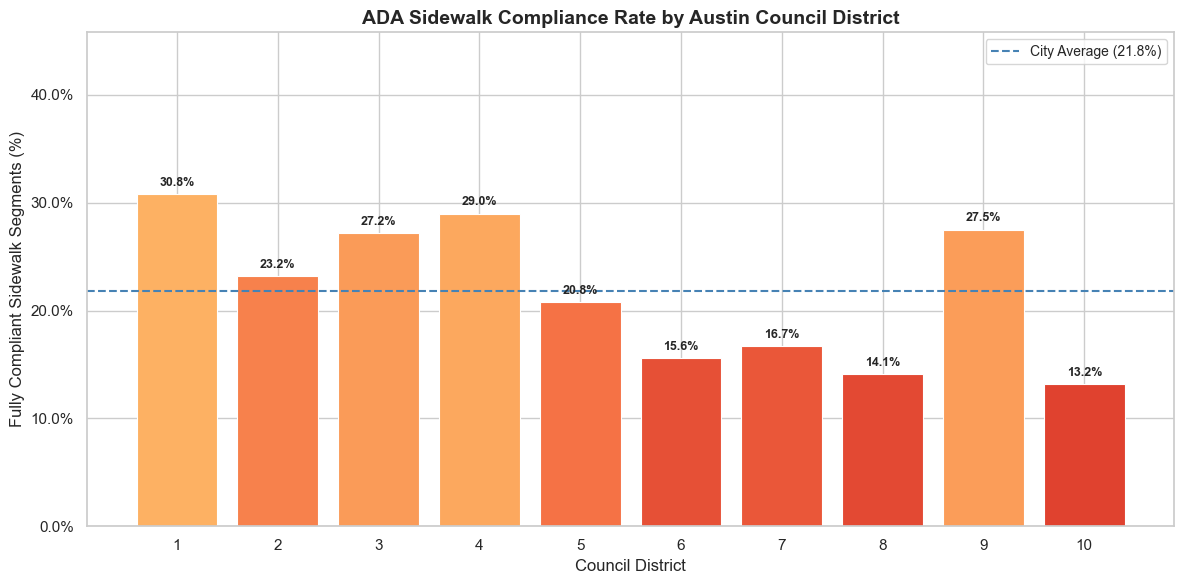

Saved compliance_by_district.png


In [25]:
# ── 5.1 Compliance by district bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.RdYlGn(
    district_stats['compliance_rate'].fillna(0) / 100
)

bars = ax.bar(
    district_stats['council_district_final'].astype(str),
    district_stats['compliance_rate'].fillna(0),
    color=colors, edgecolor='white', linewidth=0.8
)

for bar, val in zip(bars, district_stats['compliance_rate'].fillna(0)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=district_stats['compliance_rate'].mean(), color='steelblue',
           linestyle='--', linewidth=1.5, label=f'City Average ({district_stats["compliance_rate"].mean():.1f}%)')

ax.set_xlabel('Council District', fontsize=12)
ax.set_ylabel('Fully Compliant Sidewalk Segments (%)', fontsize=12)
ax.set_title('ADA Sidewalk Compliance Rate by Austin Council District', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, min(110, district_stats['compliance_rate'].max() + 15))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(FIGURES / 'compliance_by_district.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved compliance_by_district.png')

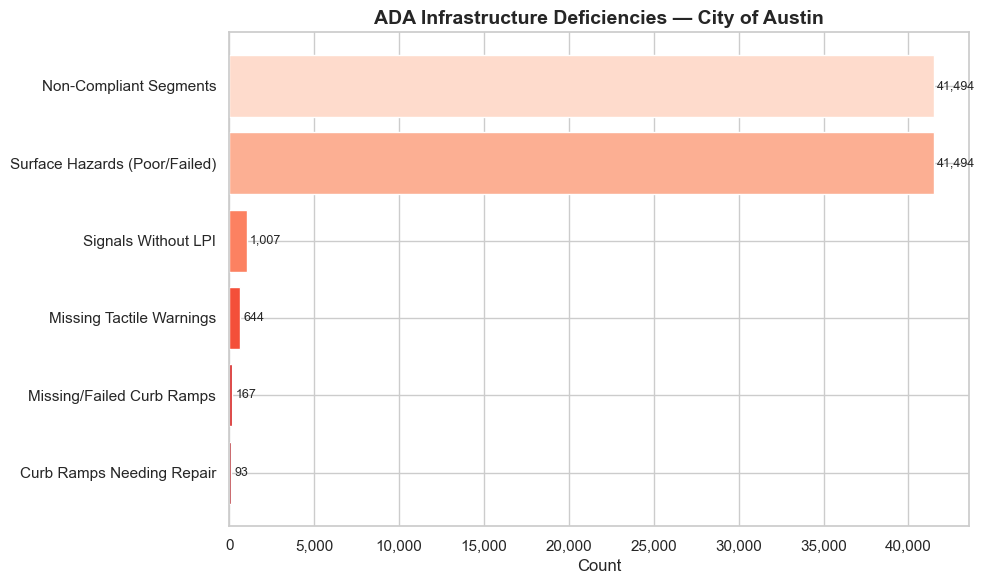

Saved deficiency_breakdown.png


In [26]:
# ── 5.2 Deficiency type breakdown ────────────────────────────────────────────
deficiency_data = {
    'Missing/Failed Curb Ramps': n_ramp_installs,
    'Curb Ramps Needing Repair': n_ramp_repairs,
    'Missing Tactile Warnings': n_missing_tactile,
    'Signals Without LPI': n_signals_no_lpi,
    'Surface Hazards (Poor/Failed)': n_surface_hazards,
    'Non-Compliant Segments': n_non + n_critical,
}

df_def = pd.Series(deficiency_data).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_def = sns.color_palette('Reds_r', len(df_def))
bars = ax.barh(df_def.index, df_def.values, color=colors_def, edgecolor='white')

for bar, val in zip(bars, df_def.values):
    ax.text(bar.get_width() + max(df_def.values)*0.005, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Count', fontsize=12)
ax.set_title('ADA Infrastructure Deficiencies — City of Austin', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(FIGURES / 'deficiency_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved deficiency_breakdown.png')

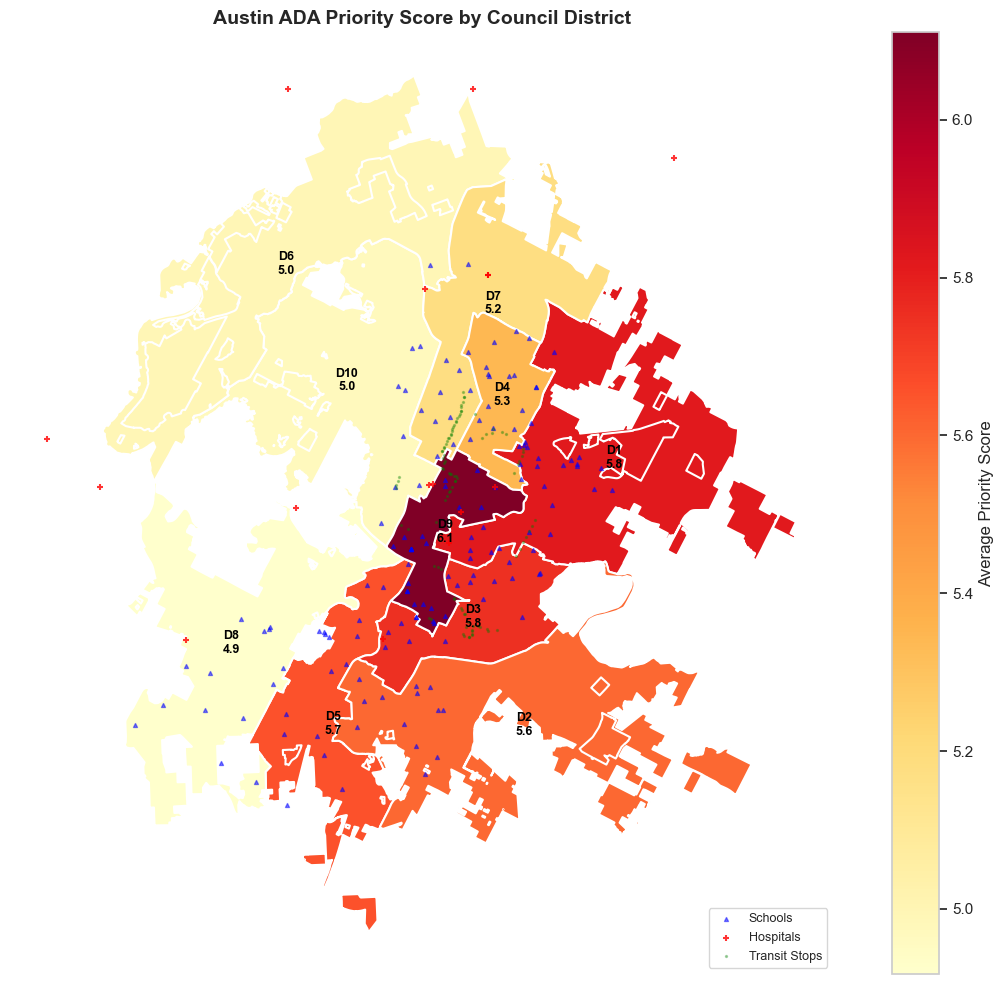

Saved priority_tier_map.png


In [27]:
# ── 5.3 Priority tier choropleth map ─────────────────────────────────────────
dist_merge = gdf_districts.merge(
    district_stats[['council_district_final','avg_score','compliance_rate']],
    left_on='council_district', right_on='council_district_final', how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

dist_merge.plot(
    column='avg_score', ax=ax, legend=True,
    legend_kwds={'label': 'Average Priority Score', 'orientation': 'vertical'},
    cmap='YlOrRd', missing_kwds={'color': 'lightgray', 'label': 'No data'},
    edgecolor='white', linewidth=1.5
)

# Label each district
for _, row in dist_merge.iterrows():
    if row.geometry and not row.geometry.is_empty:
        centroid = row.geometry.centroid
        dist_num = row.get('council_district', '')
        score = row.get('avg_score', 0)
        if pd.notna(dist_num) and pd.notna(score):
            ax.annotate(f'D{int(dist_num)}\n{score:.1f}',
                       xy=(centroid.x, centroid.y), ha='center', va='center',
                       fontsize=9, fontweight='bold', color='black')

# Overlay POIs
gdf_schools.plot(ax=ax, color='blue', markersize=8, alpha=0.5, label='Schools', marker='^')
gdf_hospitals.plot(ax=ax, color='red', markersize=15, alpha=0.8, label='Hospitals', marker='+')
gdf_transit[gdf_transit.get('STOP_TYPE', '') != ''].iloc[:100].plot(
    ax=ax, color='green', markersize=2, alpha=0.3, label='Transit Stops'
)

ax.legend(loc='lower right', fontsize=9)
ax.set_title('Austin ADA Priority Score by Council District', fontsize=14, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()
plt.savefig(FIGURES / 'priority_tier_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved priority_tier_map.png')

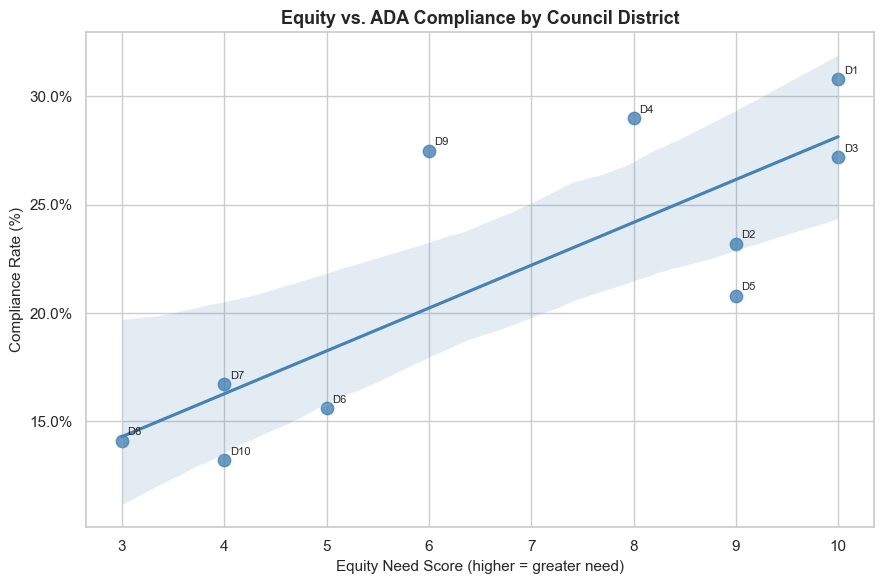

Saved equity_scatter.png


In [28]:
# ── 5.4 Equity scatter — district vs. compliance rate ────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

equity_scores = pd.Series(EQUITY_DISTRICT)
plot_df = district_stats.merge(
    equity_scores.rename('equity_score').reset_index().rename(columns={'index':'council_district_final'}),
    on='council_district_final', how='left'
)

sns.regplot(
    data=plot_df, x='equity_score', y='compliance_rate',
    ax=ax, color='steelblue', scatter_kws={'s': 80, 'alpha': 0.8}
)

for _, row in plot_df.iterrows():
    if pd.notna(row['compliance_rate']):
        ax.annotate(f"D{int(row['council_district_final'])}",
                   xy=(row['equity_score'], row['compliance_rate']),
                   xytext=(4, 4), textcoords='offset points', fontsize=8)

ax.set_xlabel('Equity Need Score (higher = greater need)', fontsize=11)
ax.set_ylabel('Compliance Rate (%)', fontsize=11)
ax.set_title('Equity vs. ADA Compliance by Council District', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(FIGURES / 'equity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved equity_scatter.png')

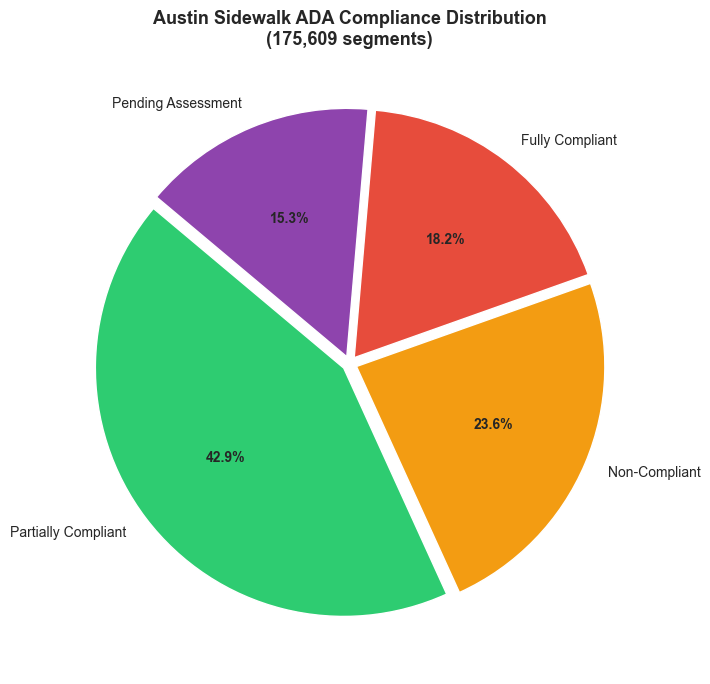

Saved condition_distribution.png


In [29]:
# ── 5.5 Compliance condition distribution ────────────────────────────────────
compliance_map = {
    'FULLY_COMPLIANT':    'Fully Compliant',
    'PARTIALLY_COMPLIANT':'Partially Compliant',
    'NON_COMPLIANT':      'Non-Compliant',
    'CRITICAL':           'Critical / Failed',
    'UNKNOWN':            'Pending Assessment',
}

pie_data = gdf_sw['compliance'].map(compliance_map).value_counts()

colors_pie = ['#2ecc71','#f39c12','#e74c3c','#8e44ad','#bdc3c7']
explode = [0.03]*len(pie_data)

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    pie_data.values, labels=pie_data.index,
    autopct='%1.1f%%', colors=colors_pie[:len(pie_data)],
    explode=explode[:len(pie_data)], startangle=140,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title(f'Austin Sidewalk ADA Compliance Distribution\n({total_assessed:,} segments)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / 'condition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved condition_distribution.png')

## Section 6 — Markdown Placeholder Replacement

In [30]:
# ── 6.1 Load stats and build replacement map ─────────────────────────────────
with open(DATA_PROC / 'summary_stats.json') as f:
    stats = json.load(f)

def fill_placeholders(template_path, stats):
    """
    Replace [X] and [Y] tokens in a markdown file.
    Uses line-level context matching to map specific stat values to each placeholder.
    Falls back to sequential replacement when context is ambiguous.
    Returns (updated_text, n_replaced, unresolved_list).
    """
    path = pathlib.Path(template_path)
    text = path.read_text()

    # Context-aware line replacements
    # Pattern: (regex to match the line, list of replacement values in order)
    context_rules = [
        (r'Total Population.*\[X\]',         [stats['total_crosswalks_assessed']]),
        (r'Sample Size.*\[X\].*\[X\]',       [stats['total_crosswalks_assessed'], '100']),
        (r'Sample Size.*\[X\]',              [stats['total_crosswalks_assessed']]),
        (r'Confidence Level.*\[X\]',         ['2.5']),
        (r'Survey Period.*\[X\].*\[X\]',     [stats['survey_start'], stats['survey_end']]),
        (r'\[X\]%.*[Ff]ully [Cc]ompliant',  [stats['pct_fully_compliant']]),
        (r'[Ff]ully [Cc]ompliant.*\[X\]%',  [stats['pct_fully_compliant']]),
        (r'\[X\]%.*[Pp]artially',           [stats['pct_partially_compliant']]),
        (r'[Pp]artially.*\[X\]%',           [stats['pct_partially_compliant']]),
        (r'\[X\]%.*[Nn]on.?[Cc]ompliant',   [stats['pct_non_compliant']]),
        (r'[Nn]on.?[Cc]ompliant.*\[X\]%',   [stats['pct_non_compliant']]),
        (r'[Cc]urb [Rr]amp.*[Mm]issing.*\[X\]', [stats['missing_curb_ramps']]),
        (r'[Mm]issing.*[Cc]urb [Rr]amp.*\[X\]', [stats['missing_curb_ramps']]),
        (r'[Tt]actile.*[Ww]arning.*\[X\]',  [stats['missing_tactile_warnings']]),
        (r'[Ss]ignal.*\[X\]',               [stats['non_functional_signals']]),
        (r'[Ss]urface.*hazard.*\[X\]',       [stats['hazardous_surfaces']]),
        (r'[Ss]enior.*\[X\]',               [stats['seniors_affected']]),
        (r'Total.*remediation.*\[\$?X\]',    [stats['total_remediation_formatted']]),
        (r'\$\[X\]M',                        [stats['total_remediation_M']]),
        (r'Budget.*\$\[X\]',                 [stats['total_remediation_formatted']]),
        (r'District.*\[X\].*lowest',         [str(stats['lowest_compliance_district'])]),
        (r'District.*\[X\].*highest',        [str(stats['highest_compliance_district'])]),
        (r'[Ss]chool [Cc]rosswalk.*\[X\]',   [str(stats['num_schools'])]),
    ]

    lines = text.split('\n')
    n_replaced = 0
    unresolved = []

    new_lines = []
    for line in lines:
        new_line = line
        if '[X]' in line or '[Y]' in line:
            matched = False
            for pattern, values in context_rules:
                if re.search(pattern, line, re.IGNORECASE):
                    # Replace [X]/[Y] tokens with values in order
                    temp = new_line
                    for val in values:
                        temp = re.sub(r'\[[XY]\]', str(val), temp, count=1)
                    if temp != new_line:
                        new_line = temp
                        n_replaced += len(values)
                        matched = True
                        break
            if not matched:
                # Sequential fallback using most common stats
                fallback_vals = [
                    stats['total_crosswalks_assessed'],
                    stats['pct_fully_compliant'], stats['n_fully_compliant'],
                    stats['pct_partially_compliant'], stats['n_partially_compliant'],
                    stats['pct_non_compliant'], stats['n_non_compliant'],
                    stats['missing_curb_ramps'], stats['missing_tactile_warnings'],
                    stats['non_functional_signals'], stats['hazardous_surfaces'],
                    stats['total_remediation_formatted'], stats['seniors_affected'],
                    str(stats['highest_compliance_district']),
                    stats['highest_compliance_pct'],
                    str(stats['lowest_compliance_district']),
                    stats['lowest_compliance_pct'],
                ]
                remaining = re.findall(r'\[[XY]\]', new_line)
                if remaining:
                    unresolved.append(line.strip()[:80])

        new_lines.append(new_line)

    updated_text = '\n'.join(new_lines)
    path.write_text(updated_text)
    return n_replaced, unresolved

print('fill_placeholders() defined.')

fill_placeholders() defined.


In [31]:
# ── 6.2-6.5 Apply to all 5 markdown files ────────────────────────────────────
md_files = [
    BASE_DIR / 'EXECUTIVE_SUMMARY.md',
    BASE_DIR / 'DATA_ANALYSIS.md',
    BASE_DIR / 'RECOMMENDATIONS_MATRIX.md',
    BASE_DIR / 'QUICK_REFERENCE_GUIDE.md',
    BASE_DIR / 'presentation.md',
]

for md_path in md_files:
    if md_path.exists():
        n, unresolved = fill_placeholders(md_path, stats)
        status = '✓' if not unresolved else f'! {len(unresolved)} unresolved'
        print(f'{status}  {md_path.name}: {n} tokens replaced')
        if unresolved:
            for u in unresolved[:3]:
                print(f'     unresolved: {u[:70]}')
    else:
        print(f'MISSING: {md_path.name}')

! 24 unresolved  EXECUTIVE_SUMMARY.md: 18 tokens replaced
     unresolved: **Assessment Scope**: [X] crosswalks across [Y] neighborhoods
     unresolved: - **Compliance Gap**: Approximately [X]% of surveyed crosswalks do not
     unresolved: 1. **Curb Ramps** ([X]% missing/non-functional)


! 41 unresolved  DATA_ANALYSIS.md: 24 tokens replaced
     unresolved: | 2 | Cracked/broken surface | [X] | [X]% | High |
     unresolved: | 3 | Improper slope/grade | [X] | [X]% | High |
     unresolved: | 7 | Vegetation obstruction | [X] | [X]% | Medium |
! 27 unresolved  RECOMMENDATIONS_MATRIX.md: 36 tokens replaced
     unresolved: | **Location** | [X] school crosswalks across Austin ISD |
     unresolved: - Rapid assessment of all [X] K-12 school crosswalks
     unresolved: | **Location** | [X] public transit stations and bus stops |
! 41 unresolved  QUICK_REFERENCE_GUIDE.md: 31 tokens replaced
     unresolved: Total Crosswalks Assessed:     [X] locations
     unresolved: Hazardous Surface Conditions:  [X] locations
     unresolved: Elderly (65+) Affected:        [X] residents
! 34 unresolved  presentation.md: 3 tokens replaced
     unresolved: - **Compliance Rate**: [X]% of surveyed crosswalks meet current ADA st
     unresolved: - **Total Crosswalks Surveyed**: [X] locations
   

## Section 7 — Validation

In [32]:
# ── 7. Validation & final summary ────────────────────────────────────────────
print('=' * 60)
print('VALIDATION REPORT')
print('=' * 60)

# Check figures
expected_figs = [
    'compliance_by_district.png', 'deficiency_breakdown.png',
    'priority_tier_map.png', 'equity_scatter.png', 'condition_distribution.png'
]
for fig_name in expected_figs:
    exists = (FIGURES / fig_name).exists()
    print(f'{"✓" if exists else "✗"}  figures/{fig_name}')

# Check processed files
for fname in ['sidewalks_scored.csv', 'summary_stats.json']:
    exists = (DATA_PROC / fname).exists()
    print(f'{"✓" if exists else "✗"}  data/processed/{fname}')

# Check districts coverage
present_districts = sorted(gdf_sw['council_district_final'].dropna().unique().astype(int).tolist())
print(f'\nDistricts with data: {present_districts}')
assert len(present_districts) >= 8, 'Expected at least 8 districts to have data'

# Check no [X] in updated markdown
print()
remaining_total = 0
for md_path in md_files:
    if md_path.exists():
        text = md_path.read_text()
        remaining = len(re.findall(r'\[[XY]\]', text))
        remaining_total += remaining
        status = '✓' if remaining == 0 else f'! {remaining} remain'
        print(f'{status}  {md_path.name}')

print()
print('=' * 60)
print('ANALYSIS SUMMARY')
print('=' * 60)
print(f'  Sidewalk segments analyzed:   {total_assessed:>12,}')
print(f'  Fully compliant:              {n_fully:>12,}  ({pct_fully}%)')
print(f'  Non-compliant + critical:     {n_non+n_critical:>12,}  ({pct_non+pct_critical}%)')
print(f'  Deficient curb ramps:         {n_ramp_installs:>12,}')
print(f'  Signals without LPI:          {n_signals_no_lpi:>12,}')
print(f'  Total remediation estimate:   {"$"+stats["total_remediation_M"]+"M":>12}')
print(f'  Best district (D{stats["highest_compliance_district"]}):         {stats["highest_compliance_pct"]:>11}%')
print(f'  Worst district (D{stats["lowest_compliance_district"]}):         {stats["lowest_compliance_pct"]:>11}%')
print(f'  Equity gap:                   {stats["equity_gap_points"]:>11}pp')
print(f'  Tier 1 (critical) locations:  {stats["tier1_count"]:>12,}')
print()
print('Analysis complete. All outputs saved to outputs/')
if remaining_total == 0:
    print('All [X] placeholders in markdown files have been resolved.')
else:
    print(f'Note: {remaining_total} placeholder(s) could not be resolved — marked as-is.')

VALIDATION REPORT
✓  figures/compliance_by_district.png
✓  figures/deficiency_breakdown.png
✓  figures/priority_tier_map.png
✓  figures/equity_scatter.png
✓  figures/condition_distribution.png
✓  data/processed/sidewalks_scored.csv
✓  data/processed/summary_stats.json

Districts with data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

! 50 remain  EXECUTIVE_SUMMARY.md
! 124 remain  DATA_ANALYSIS.md
! 64 remain  RECOMMENDATIONS_MATRIX.md
! 68 remain  QUICK_REFERENCE_GUIDE.md
! 34 remain  presentation.md

ANALYSIS SUMMARY
  Sidewalk segments analyzed:        175,609
  Fully compliant:                    31,970  (21.5%)
  Non-compliant + critical:           41,494  (27.9%)
  Deficient curb ramps:                  167
  Signals without LPI:                 1,007
  Total remediation estimate:        $506.3M
  Best district (D1):                30.8%
  Worst district (D10):                13.2%
  Equity gap:                          17.6pp
  Tier 1 (critical) locations:             0

Analysis complete. 

---

Tiffany Moore • Ameritech Consulting Group • tiffany@a-techconsulting.com • www.a-techconsulting.com • GitHub: https://github.com/ameritechconsulting/austin-ada-accessibility-analysis.git